In [7]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Load dataset
df = pd.read_csv('cleaned_data.csv')

# Define features (X) and target (y)
X = df.drop(columns=['HasPay'])  # Ensure we exclude the target variable
y = df['HasPay']

# Identify categorical and numerical features
categorical_features = X.select_dtypes(include=['object']).columns.tolist()
numerical_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Define preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', SimpleImputer(strategy='median'), numerical_features),  # Fill NaNs in numeric columns with median
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),  # Fill NaNs in categorical columns
            ('onehot', OneHotEncoder(handle_unknown='ignore'))  # One-Hot Encoding
        ]), categorical_features)
    ])

# Apply preprocessing to features
X_processed = preprocessor.fit_transform(X)

# Train-Test Split BEFORE SMOTE to prevent data leakage
X_train, X_test, y_train, y_test = train_test_split(X_processed, y, test_size=0.3, random_state=42, stratify=y)

# Apply SMOTE only on the training set
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# Initialize Random Forest with regularization to prevent overfitting
rf_model = RandomForestClassifier(n_estimators=100, max_depth=10, min_samples_split=10, min_samples_leaf=5, random_state=42)

# Cross-validation on the resampled training set
cv_scores = cross_val_score(rf_model, X_train_resampled, y_train_resampled, cv=5)
print(f"Cross-validation Scores: {cv_scores}")
print(f"Mean CV Accuracy: {cv_scores.mean():.4f}")

# Train the model on resampled data
rf_model.fit(X_train_resampled, y_train_resampled)

# Evaluate on the original test set (not oversampled)
y_pred = rf_model.predict(X_test)

# Model Performance Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Model Performance on Original Test Set:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))


Cross-validation Scores: [0.91666667 0.96727273 0.98181818 0.97090909 0.98181818]
Mean CV Accuracy: 0.9637
Model Performance on Original Test Set:
Accuracy: 0.9527
Precision: 0.7500
Recall: 0.4286
F1 Score: 0.5455

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.99      0.98       296
           1       0.75      0.43      0.55        21

    accuracy                           0.95       317
   macro avg       0.86      0.71      0.76       317
weighted avg       0.95      0.95      0.95       317


Confusion Matrix:
[[293   3]
 [ 12   9]]


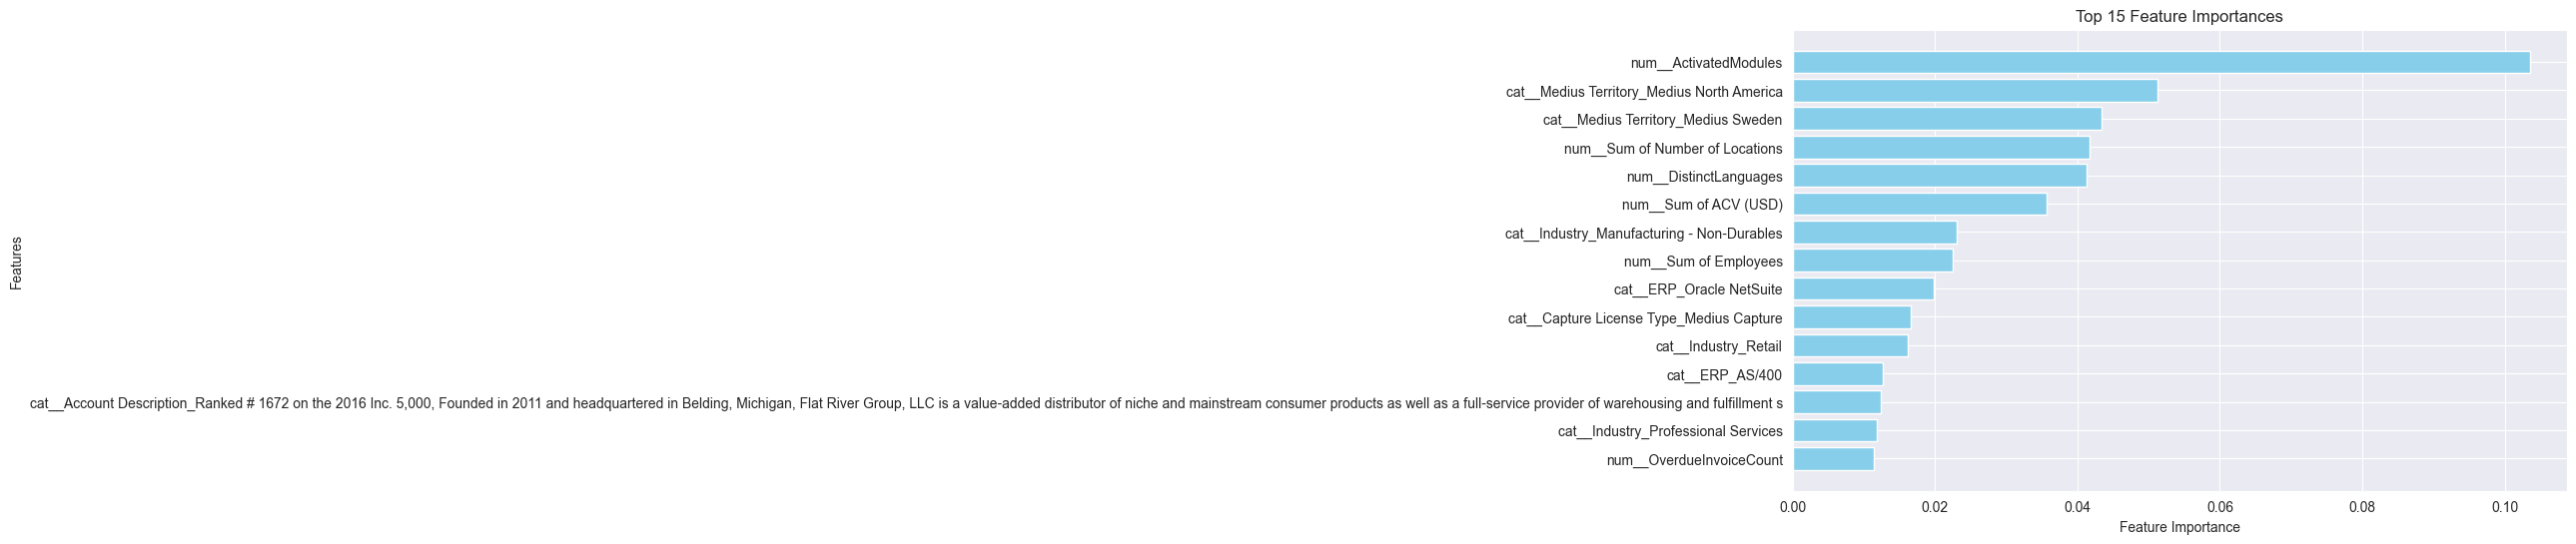

                                                Feature  Importance
4                                 num__ActivatedModules    0.103492
1380         cat__Medius Territory_Medius North America    0.051286
1382                cat__Medius Territory_Medius Sweden    0.043447
3                       num__Sum of Number of Locations    0.041669
12                               num__DistinctLanguages    0.041314
2                                 num__Sum of ACV (USD)    0.035617
1084         cat__Industry_Manufacturing - Non-Durables    0.023071
0                                 num__Sum of Employees    0.022434
1332                           cat__ERP_Oracle NetSuite    0.019856
1386           cat__Capture License Type_Medius Capture    0.016657
1094                               cat__Industry_Retail    0.016180
1223                                    cat__ERP_AS/400    0.012618
4175  cat__Account Description_Ranked # 1672 on the ...    0.012377
1092                cat__Industry_Professional S

In [8]:
import matplotlib.pyplot as plt

# Get feature importances
feature_importances = rf_model.feature_importances_

# Get feature names after One-Hot Encoding
feature_names = preprocessor.get_feature_names_out()

# Create a DataFrame for better visualization
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': feature_importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Plot feature importance
plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'][:15], importance_df['Importance'][:15], color='skyblue')
plt.xlabel("Feature Importance")
plt.ylabel("Features")
plt.title("Top 15 Feature Importances")
plt.gca().invert_yaxis()  # Invert y-axis for better readability
plt.show()

# Print top features
print(importance_df.head(15))


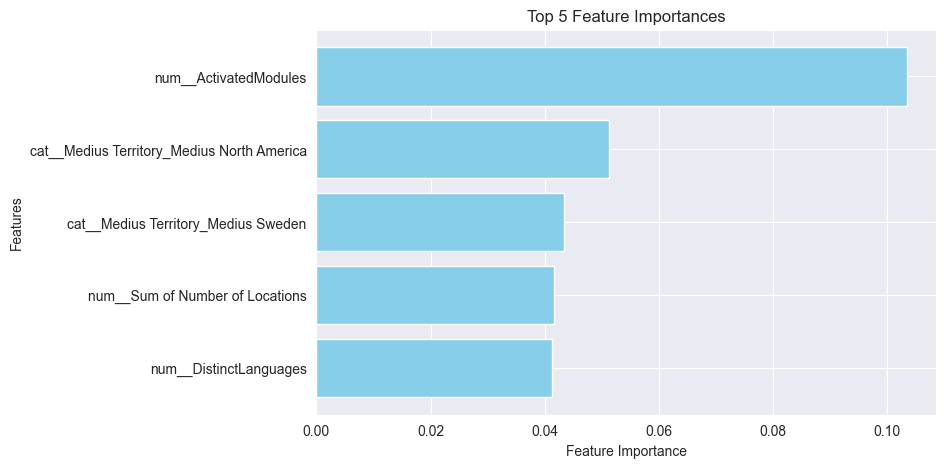

                                         Feature  Importance
4                          num__ActivatedModules    0.103492
1380  cat__Medius Territory_Medius North America    0.051286
1382         cat__Medius Territory_Medius Sweden    0.043447
3                num__Sum of Number of Locations    0.041669
12                        num__DistinctLanguages    0.041314


In [9]:
# Get top 5 most important features
top_features = importance_df.head(5)

# Plot top 5 feature importance
plt.figure(figsize=(8, 5))
plt.barh(top_features['Feature'], top_features['Importance'], color='skyblue')
plt.xlabel("Feature Importance")
plt.ylabel("Features")
plt.title("Top 5 Feature Importances")
plt.gca().invert_yaxis()  # Invert y-axis for better readability
plt.show()

# Print top 5 features
print(top_features)


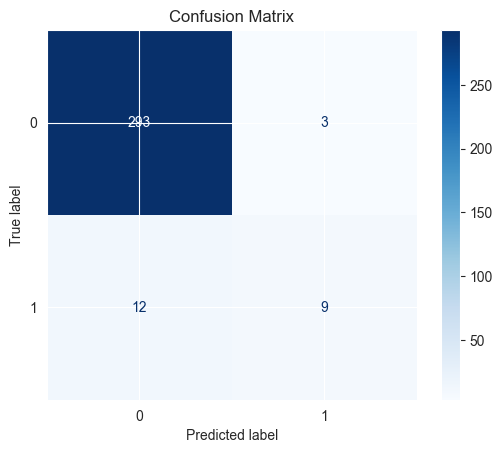

In [10]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Generate the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Display the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()
